<a href="https://www.kaggle.com/code/samithsachidanandan/churn-prediction-xgb-lgbm-ensemble?scriptVersionId=301385112" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import TargetEncoder

from sklearn.model_selection import ParameterSampler
from scipy.optimize import minimize
import random

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from scipy.optimize import minimize_scalar

import warnings
warnings.filterwarnings('ignore')
#sns.set_theme(style="whitegrid")

# Load the Data

In [9]:
# Load the data

train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')
orig = pd.read_csv('/kaggle/input/datasets/cdeotte/s6e3-original-dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Standardize Target
train['Churn'] = train['Churn'].map({'No': 0, 'Yes': 1})
orig['Churn'] = orig['Churn'].map({'No': 0, 'Yes': 1})

# THE FIX: Prevent "TotalCharges" numeric errors
for df in [train, test, orig]:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
    df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce').fillna(0)
    df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce').fillna(0)

CATS = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
        'InternetService', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
        'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
NUMS = ['tenure', 'MonthlyCharges', 'TotalCharges']


In [10]:
train.describe().style.background_gradient(cmap='tab20c')

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057,0.225208
std,171529.177262,0.317936,25.061922,31.067444,2353.916710,0.417719
min,0.000000,0.000000,1.000000,18.250000,18.800000,0.000000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000,0.000000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000,0.000000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000,0.000000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000,1.000000


# Feature Engineering

In [11]:
# Feature Engineering (Frequencies & Probas)

NEW_NUMS = []
# Frequency Encoding
for cat in NUMS:
    freq = pd.concat([train[cat], orig[cat], test[cat]]).value_counts(normalize=True)
    for df in [train, test, orig]:
        df[f'FREQ_{cat}'] = df[cat].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{cat}')

# Original Dataset Probabilities (Statistical Alignment)
for col in CATS + NUMS:
    _new_col = f"ORIG_proba_{col}"
    # FIX: Group by, then rename the resulting Churn column immediately
    tmp = orig.groupby(col)['Churn'].mean().reset_index().rename(columns={'Churn': _new_col})
    
    train = train.merge(tmp, on=col, how="left")
    test = test.merge(tmp, on=col, how="left")
    
    # Now that the column exists with the right name, we can fillna
    train[_new_col] = train[_new_col].fillna(0.5)
    test[_new_col] = test[_new_col].fillna(0.5)
    NEW_NUMS.append(_new_col)

# Prepare Features
FEATURES = NUMS + CATS + NEW_NUMS
# Ensure categorical types for XGBoost
for df in [train, test]:
    df[CATS] = df[CATS].astype(str).astype('category')

# Model Training 

In [12]:
SEED        = 11
FOLDS       = 5
INNER_FOLDS = 5

XGB_PARAMS = {
    'n_estimators'         : 50_000,
    'learning_rate'        : 0.05,
    'max_depth'            : 6,
    'subsample'            : 0.8,
    'colsample_bytree'     : 0.8,
    'min_child_weight'     : 5,
    'reg_alpha'            : 0.1,
    'reg_lambda'           : 1.0,
    'gamma'                : 0.05,
    'random_state'         : SEED,
    'early_stopping_rounds': 500,
    'objective'            : 'binary:logistic',
    'eval_metric'          : 'auc',
    'enable_categorical'   : True,
    'device'               : 'cuda',
    'tree_method'          : 'hist',
    'verbosity'            : 0,
    'n_jobs'               : -1,
}

LGB_PARAMS = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'learning_rate'    : 0.05,
    'num_leaves'       : 63,
    'max_depth'        : 7,
    'subsample'        : 0.8,
    'subsample_freq'   : 1,
    'colsample_bytree' : 0.8,
    'min_child_samples': 20,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'n_estimators'     : 50_000,
    'random_state'     : SEED,
    'device'           : 'gpu',
    'n_jobs'           : -1,
    'verbose'          : -1,
}

CAT_PARAMS = {
    'loss_function'        : 'Logloss',
    'eval_metric'          : 'AUC',
    'learning_rate'        : 0.05,
    'depth'                : 6,
    'l2_leaf_reg'          : 3.0,
    'iterations'           : 10_000,
    'early_stopping_rounds': 500,
    'random_seed'          : SEED,
    'verbose'              : False,
    'task_type'            : 'GPU',
    'thread_count'         : -1,
}


kf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)

oof_xgb  = np.zeros(len(train))
oof_lgb  = np.zeros(len(train))
oof_cat  = np.zeros(len(train))
pred_xgb = np.zeros(len(test))
pred_lgb = np.zeros(len(test))
pred_cat = np.zeros(len(test))

importances_xgb     = []
importances_lgb     = []
importances_cat     = []
best_iterations_xgb = []
best_iterations_lgb = []
best_iterations_cat = []
fold_aucs_xgb       = []
fold_aucs_lgb       = []
fold_aucs_cat       = []
fold_aucs_ens       = []


for i, (train_index, val_index) in enumerate(kf.split(train, train['Churn'])):
    print(f"\n{'='*55}")
    print(f"  Fold {i+1}/{FOLDS}")
    print(f"{'='*55}")

    X_train = train.loc[train_index, FEATURES].copy()
    y_train = train.loc[train_index, 'Churn'].values
    X_val   = train.loc[val_index,   FEATURES].copy()
    y_val   = train.loc[val_index,   'Churn'].values
    X_test  = test[FEATURES].copy()

    # Target encode for XGB & LGB
    te = TargetEncoder(cv=INNER_FOLDS, random_state=SEED)
    X_train_enc        = X_train.copy()
    X_val_enc          = X_val.copy()
    X_test_enc         = X_test.copy()
    X_train_enc[CATS]  = te.fit_transform(X_train[CATS], y_train)
    X_val_enc[CATS]    = te.transform(X_val[CATS])
    X_test_enc[CATS]   = te.transform(X_test[CATS])


    xgb_model = xgb.XGBClassifier(**XGB_PARAMS)
    xgb_model.fit(
        X_train_enc, y_train,
        eval_set=[(X_val_enc, y_val)],
        verbose=False,
    )
    best_iterations_xgb.append(xgb_model.best_iteration)
    xgb_val_pred  = xgb_model.predict_proba(X_val_enc)[:, 1]
    xgb_test_pred = xgb_model.predict_proba(X_test_enc)[:, 1]
    importances_xgb.append(xgb_model.get_booster().get_score(importance_type='gain'))
    fold_aucs_xgb.append(roc_auc_score(y_val, xgb_val_pred))
    print(f"  XGB  best iter : {xgb_model.best_iteration}")
    print(f"  XGB  Fold AUC  : {fold_aucs_xgb[-1]:.5f}")


    lgb_model = lgb.LGBMClassifier(**LGB_PARAMS)
    lgb_model.fit(
        X_train_enc, y_train,
        eval_set=[(X_val_enc, y_val)],
        callbacks=[lgb.early_stopping(500, verbose=False),
                   lgb.log_evaluation(period=-1)],
    )
    best_iterations_lgb.append(lgb_model.best_iteration_)
    lgb_val_pred  = lgb_model.predict_proba(X_val_enc)[:, 1]
    lgb_test_pred = lgb_model.predict_proba(X_test_enc)[:, 1]
    importances_lgb.append(dict(zip(FEATURES, lgb_model.feature_importances_)))
    fold_aucs_lgb.append(roc_auc_score(y_val, lgb_val_pred))
    print(f"  LGB  best iter : {lgb_model.best_iteration_}")
    print(f"  LGB  Fold AUC  : {fold_aucs_lgb[-1]:.5f}")


    cat_model = CatBoostClassifier(**CAT_PARAMS)
    cat_model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=CATS,
        use_best_model=True,
    )
    best_iterations_cat.append(cat_model.best_iteration_)
    cat_val_pred  = cat_model.predict_proba(X_val)[:, 1]
    cat_test_pred = cat_model.predict_proba(X_test)[:, 1]
    importances_cat.append(dict(zip(FEATURES, cat_model.get_feature_importance())))
    fold_aucs_cat.append(roc_auc_score(y_val, cat_val_pred))
    print(f"  CAT  best iter : {cat_model.best_iteration_}")
    print(f"  CAT  Fold AUC  : {fold_aucs_cat[-1]:.5f}")


    oof_xgb[val_index] = xgb_val_pred
    oof_lgb[val_index] = lgb_val_pred
    oof_cat[val_index] = cat_val_pred
    pred_xgb          += xgb_test_pred / FOLDS
    pred_lgb          += lgb_test_pred / FOLDS
    pred_cat          += cat_test_pred / FOLDS

    ens_val = (xgb_val_pred + lgb_val_pred + cat_val_pred) / 3
    fold_aucs_ens.append(roc_auc_score(y_val, ens_val))
    print(f"  ENS  Fold AUC  : {fold_aucs_ens[-1]:.5f}")

print(f"\n{'='*55}")
print(f"  XGB  OOF AUC  : {roc_auc_score(train['Churn'], oof_xgb):.5f}")
print(f"  LGB  OOF AUC  : {roc_auc_score(train['Churn'], oof_lgb):.5f}")
print(f"  CAT  OOF AUC  : {roc_auc_score(train['Churn'], oof_cat):.5f}")
print(f"  XGB  Mean AUC : {np.mean(fold_aucs_xgb):.5f}  ±  {np.std(fold_aucs_xgb):.5f}")
print(f"  LGB  Mean AUC : {np.mean(fold_aucs_lgb):.5f}  ±  {np.std(fold_aucs_lgb):.5f}")
print(f"  CAT  Mean AUC : {np.mean(fold_aucs_cat):.5f}  ±  {np.std(fold_aucs_cat):.5f}")
print(f"  ENS  Mean AUC : {np.mean(fold_aucs_ens):.5f}  ±  {np.std(fold_aucs_ens):.5f}")
print(f"  XGB  mean iter: {np.mean(best_iterations_xgb):.0f}")
print(f"  LGB  mean iter: {np.mean(best_iterations_lgb):.0f}")
print(f"  CAT  mean iter: {np.mean(best_iterations_cat):.0f}")
print(f"{'='*55}")




  Fold 1/5
  XGB  best iter : 681
  XGB  Fold AUC  : 0.91542
  LGB  best iter : 715
  LGB  Fold AUC  : 0.91538


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT  best iter : 2072
  CAT  Fold AUC  : 0.91491
  ENS  Fold AUC  : 0.91559

  Fold 2/5
  XGB  best iter : 858
  XGB  Fold AUC  : 0.91618
  LGB  best iter : 957
  LGB  Fold AUC  : 0.91615


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT  best iter : 2136
  CAT  Fold AUC  : 0.91594
  ENS  Fold AUC  : 0.91648

  Fold 3/5
  XGB  best iter : 952
  XGB  Fold AUC  : 0.91696
  LGB  best iter : 729
  LGB  Fold AUC  : 0.91688


...

  CAT  best iter : 2110
  CAT  Fold AUC  : 0.91663
  ENS  Fold AUC  : 0.91718

  Fold 4/5
  XGB  best iter : 892
  XGB  Fold AUC  : 0.91742
  LGB  best iter : 624
  LGB  Fold AUC  : 0.91728


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT  best iter : 2026
  CAT  Fold AUC  : 0.91689
  ENS  Fold AUC  : 0.91755

  Fold 5/5
  XGB  best iter : 762
  XGB  Fold AUC  : 0.91634
  LGB  best iter : 921
  LGB  Fold AUC  : 0.91649


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT  best iter : 2290
  CAT  Fold AUC  : 0.91593
  ENS  Fold AUC  : 0.91663

  XGB  OOF AUC  : 0.91645
  LGB  OOF AUC  : 0.91642
  CAT  OOF AUC  : 0.91606
  XGB  Mean AUC : 0.91646  ±  0.00068
  LGB  Mean AUC : 0.91643  ±  0.00065
  CAT  Mean AUC : 0.91606  ±  0.00069
  ENS  Mean AUC : 0.91669  ±  0.00067
  XGB  mean iter: 829
  LGB  mean iter: 789
  CAT  mean iter: 2127


In [15]:

def neg_auc(weights):
    w = np.array(weights)
    w = w / w.sum()
    blend = w[0]*oof_xgb + w[1]*oof_lgb + w[2]*oof_cat
    return -roc_auc_score(train['Churn'], blend)

result = minimize(neg_auc, x0=[1/3, 1/3, 1/3], method='Nelder-Mead',
                  options={'maxiter': 1000, 'xatol': 1e-6})
w = np.array(result.x)
w = w / w.sum()
print(f"\n  Optimal weights — XGB: {w[0]:.4f}  LGB: {w[1]:.4f}  CAT: {w[2]:.4f}")

oof_final  = w[0]*oof_xgb  + w[1]*oof_lgb  + w[2]*oof_cat
pred_final = w[0]*pred_xgb + w[1]*pred_lgb + w[2]*pred_cat
print(f"  Optimised OOF AUC  : {roc_auc_score(train['Churn'], oof_final):.5f}")






  Optimal weights — XGB: 0.4006  LGB: 0.3916  CAT: 0.2078
  Optimised OOF AUC  : 0.91669


# Visual Dashboard

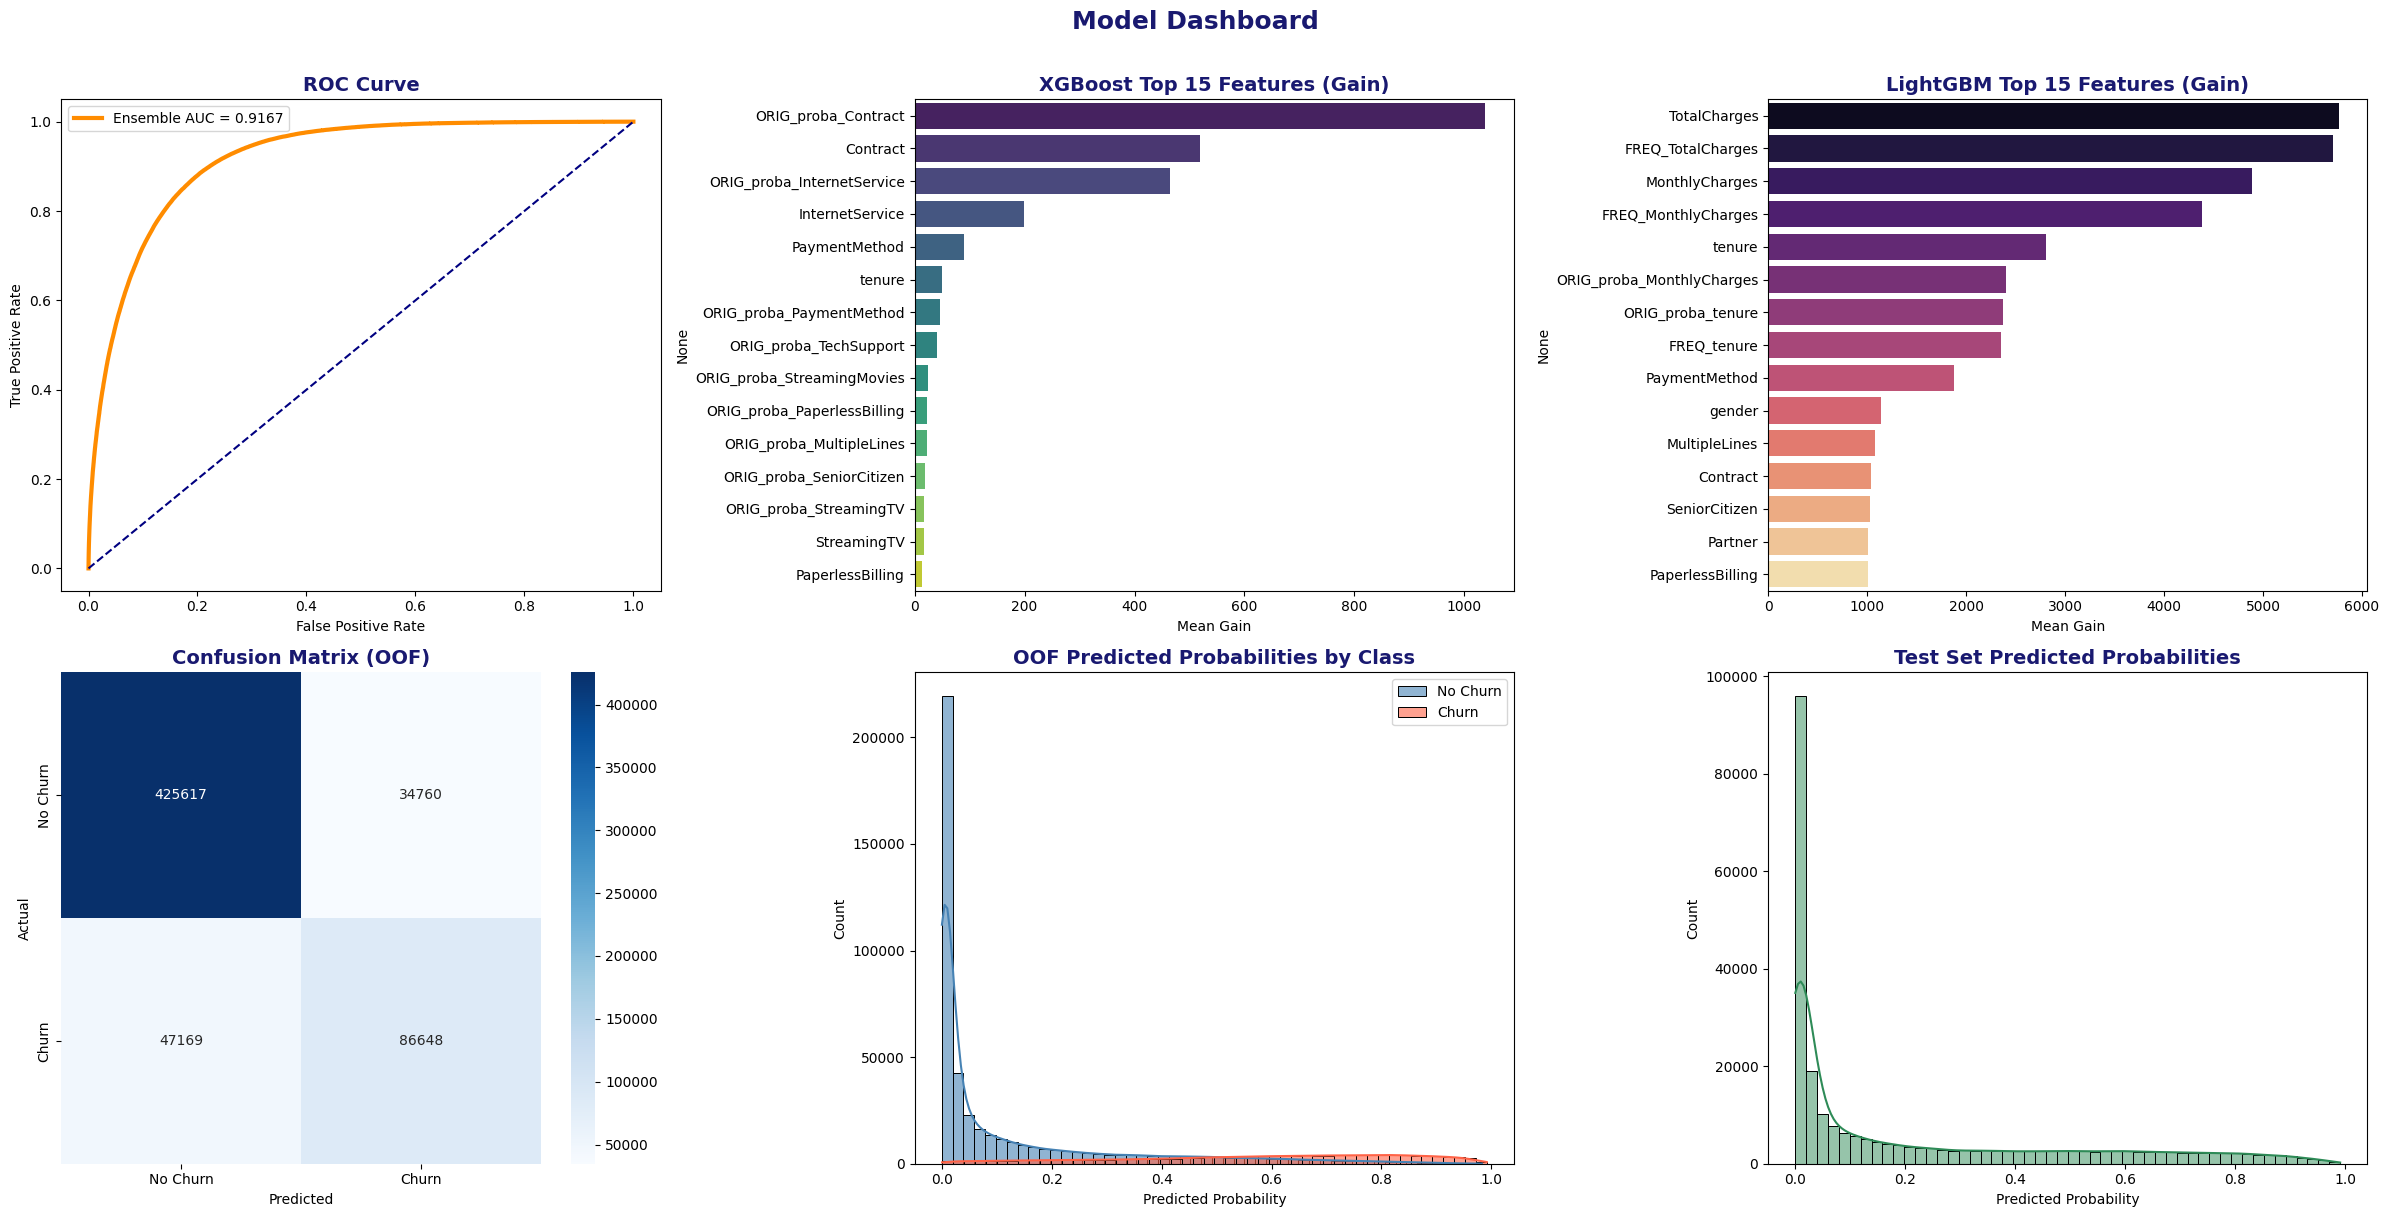

In [16]:
# Visual Dashboard

def plot_dashboard(y_true, oof_preds, test_preds, imp_xgb, imp_lgb, feat_names):
    fig, axes = plt.subplots(2, 3, figsize=(24, 12))
    fig.suptitle('Model Dashboard', fontsize=18, fontweight='bold', color='midnightblue', y=1.01)


    fpr, tpr, _ = roc_curve(y_true, oof_preds)
    axes[0, 0].plot(fpr, tpr, color='darkorange', lw=3, label=f'Ensemble AUC = {auc(fpr, tpr):.4f}')
    axes[0, 0].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[0, 0].set_title('ROC Curve', fontsize=14, fontweight='bold', color='midnightblue')
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].legend()


    xgb_imps = pd.DataFrame(imp_xgb).fillna(0).mean().sort_values(ascending=False).head(15)
    sns.barplot(x=xgb_imps.values, y=xgb_imps.index, ax=axes[0, 1], palette='viridis')
    axes[0, 1].set_title('XGBoost Top 15 Features (Gain)', fontsize=14, fontweight='bold', color='midnightblue')
    axes[0, 1].set_xlabel('Mean Gain')


    lgb_imps = pd.DataFrame(imp_lgb).fillna(0).mean().sort_values(ascending=False).head(15)
    sns.barplot(x=lgb_imps.values, y=lgb_imps.index, ax=axes[0, 2], palette='magma')
    axes[0, 2].set_title('LightGBM Top 15 Features (Gain)', fontsize=14, fontweight='bold', color='midnightblue')
    axes[0, 2].set_xlabel('Mean Gain')


    cm = confusion_matrix(y_true, (oof_preds > 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    axes[1, 0].set_title('Confusion Matrix (OOF)', fontsize=14, fontweight='bold', color='midnightblue')
    axes[1, 0].set_xlabel('Predicted')
    axes[1, 0].set_ylabel('Actual')


    sns.histplot(oof_preds[y_true == 0], bins=50, kde=True, color='steelblue',
                 label='No Churn', ax=axes[1, 1], alpha=0.6)
    sns.histplot(oof_preds[y_true == 1], bins=50, kde=True, color='tomato',
                 label='Churn', ax=axes[1, 1], alpha=0.6)
    axes[1, 1].set_title('OOF Predicted Probabilities by Class', fontsize=14, fontweight='bold', color='midnightblue')
    axes[1, 1].set_xlabel('Predicted Probability')
    axes[1, 1].legend()


    sns.histplot(test_preds, bins=50, kde=True, color='seagreen', ax=axes[1, 2])
    axes[1, 2].set_title('Test Set Predicted Probabilities', fontsize=14, fontweight='bold', color='midnightblue')
    axes[1, 2].set_xlabel('Predicted Probability')

    plt.tight_layout()
    plt.show()

plot_dashboard(train['Churn'], oof_final, pred_final, importances_xgb, importances_lgb, FEATURES)




# Submission

In [17]:
submission = pd.DataFrame({'id': test['id'], 'Churn': pred_final})
submission.to_csv('submission.csv', index=False)
print("\nSubmission saved!")


Submission saved!


Acknowledgement : 
- [https://www.kaggle.com/code/jocelyndumlao/churn-prediction-0-917-auc-pipeline](https://www.kaggle.com/code/jocelyndumlao/churn-prediction-0-917-auc-pipeline)
- [https://www.kaggle.com/datasets/cdeotte/s6e3-original-dataset](https://www.kaggle.com/datasets/cdeotte/s6e3-original-dataset)

